## 1) Run GCMC sweep and build a phase diagram

This section runs short GCMC simulations at multiple $\Delta\mu_O$ values on a surface model, then uses `utils.analyze_phase_diagram_results` to create a phase diagram from the resulting structures.

> For production-quality phase boundaries, increase the number of sampled chemical potentials and GCMC steps.

In [3]:
from pathlib import Path
import sys
import numpy as np

from ase.build import fcc111, molecule
from ase.constraints import FixAtoms
from ase.io import read, write

from mace.calculators import mace_mp

from mcpy.moves import DeletionMove, InsertionMove
from mcpy.moves.move_selector import MoveSelector
from mcpy.ensembles.grand_canonical_ensemble import GrandCanonicalEnsemble
from mcpy.calculators import BaseCalculator
from mcpy.cell import CustomCell as Cell

from mcpy.utils import analyze_phase_diagram_results

In [2]:
# Download the MACE model
!wget https://github.com/ACEsuit/mace-foundations/releases/download/mace_mh_1/mace-mh-1.model

--2026-03-17 15:52:52--  https://github.com/ACEsuit/mace-foundations/releases/download/mace_mh_1/mace-mh-1.model
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/741903654/b867b47c-b670-479e-8098-368232d1dfea?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-17T15%3A44%3A04Z&rscd=attachment%3B+filename%3Dmace-mh-1.model&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-17T14%3A43%3A38Z&ske=2026-03-17T15%3A44%3A04Z&sks=b&skv=2018-11-09&sig=P4063xdU2bd8XnFZw10IW8e0SANJ4zloc9Vehp3BhwA%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3Mzc2MDk3MiwibmJmIjoxNzczNzU5MTcyLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdG

In [4]:
# --- User parameters ---
ase_calc = mace_mp(path='mace-mh-1.model',  default_dtype="float64", device="cuda", head="omat_pbe")

o2 = molecule("O2")
o2.calc = ase_calc

metal_species = "Ag"
gas_species = "O"
metal_lattice_param = 4.1755
surface_size = (3, 3, 4)
vacuum = 8

cell_bottom = 10.0
cell_height = 6.0
metal_insertion_radii = {metal_species: 2.75, gas_species: 0.0}
gas_insertion_radii = {metal_species: 2.11, gas_species: 0.0}
min_insert = 0.5

mu_metal = -2.99
delta_mu_metal = 0.0
mu_gas_ref = o2.get_potential_energy() / 2.0

delta_mu_o_values = np.linspace(-1.0, -0.2, 8)
temperature = 500

gcmc_steps = 40
write_interval = 1

relax_steps = 40
relax_fmax = 0.1

results_dir = Path("phase_diagram_demo")
results_dir.mkdir(exist_ok=True)
combined_traj_path = results_dir / "relaxed_structures.xyz"

Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /home/energystorage/.cache/mace/macempa0mediummodel
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/home/energystorage/miniconda3/envs/mcpy/lib/python3.14/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
INFO:root:CUDA version: 12.8, CUDA device: 0
INFO:root:Using head default out of  ['default']


In [5]:
def build_ag111_surface(a=4.09, size=(3, 3, 4), vacuum=10.0):
    atoms = fcc111(metal_species, a = metal_lattice_param,
                   size=surface_size, periodic=True, vacuum=vacuum)
    bottom_layer = [a.index for a in atoms if a.tag == surface_size[-1]]
    constraint = FixAtoms(indices=bottom_layer)
    atoms.set_constraint(constraint)
    return atoms


def run_gcmc_at_delta_mu(delta_mu_o, run_dir):
    run_dir.mkdir(parents=True, exist_ok=True)

    atoms = build_ag111_surface(a=metal_lattice_param, size=surface_size, vacuum=vacuum)
    
    cell_height = 5
    cell_bottom_pos = 10.411
    metal_cell_height = gas_cell_height = cell_height
    metal_cell_bottom_pos = gas_cell_bottom_pos = cell_bottom_pos
    
    cell_metal_gcmc = Cell(atoms, custom_height=metal_cell_height, bottom_z=metal_cell_bottom_pos,
                  species_radii=metal_insertion_radii) 

    cell_gas_gcmc = Cell(atoms, custom_height=gas_cell_height, bottom_z=gas_cell_bottom_pos,
                 species_radii=gas_insertion_radii) 


    calculator = BaseCalculator(ase_calc, 20, 0.2)

    seed_del1 = np.random.randint(100_000_000, 1_000_000_000)
    seed_del2 = np.random.randint(100_000_000, 1_000_000_000)
    seed_ins1 = np.random.randint(100_000_000, 1_000_000_000)
    seed_ins2 = np.random.randint(100_000_000, 1_000_000_000)
    move_list = [[10,10,10,10], # probabilities of every move type, sum is total number of moves per mc step 
             [DeletionMove(cell_metal_gcmc,
                           species=[metal_species],
                           seed=seed_del1),
              DeletionMove(cell_gas_gcmc,
                           species=[gas_species],
                           seed=seed_del2
                           ),
              InsertionMove(cell_metal_gcmc,
                            species=[metal_species],
                            min_insert=min_insert,
                            seed=seed_ins1),
              InsertionMove(cell_gas_gcmc,
                            species=[gas_species],
                            min_insert=min_insert,
                            seed=seed_ins2)]]
    move_selector = MoveSelector(*move_list)

    mus = {
        metal_species: mu_metal + delta_mu_metal,
        gas_species: mu_gas_ref + float(delta_mu_o),
    }

    traj_file = run_dir / f"gcmc_dmu_{delta_mu_o:+.3f}.xyz"
    out_file = run_dir / f"gcmc_dmu_{delta_mu_o:+.3f}.out"

    gcmc = GrandCanonicalEnsemble(
        atoms=atoms,
        cells=[cell_metal_gcmc, cell_gas_gcmc],
        calculator=calculator,
        mu=mus,
        units_type="metal",
        species=[metal_species, gas_species],
        temperature=temperature,
        move_selector=move_selector,
        outfile=str(out_file),
        trajectory_write_interval=write_interval,
        outfile_write_interval=write_interval,
        traj_file=str(traj_file),
    )

    gcmc.run(gcmc_steps)
    return traj_file

In [15]:
all_final_structures = []
run_dirs = []

for dmu in delta_mu_o_values:
    run_dir = results_dir / f"dmu_{dmu:+.3f}"
    run_dirs.append(run_dir)
    traj_file = run_gcmc_at_delta_mu(dmu, run_dir)

    traj = read(str(traj_file), ":")
    if len(traj) == 0:
        continue

    # Take the last frame as representative relaxed structure for this chemical potential.
    all_final_structures.append(traj[-1])

if len(all_final_structures) == 0:
    raise RuntimeError("No structures were produced. Check model_path and runtime logs.")

write(str(combined_traj_path), all_final_structures)
print(f"Saved {len(all_final_structures)} structures to {combined_traj_path}")

INFO:GrandCanonicalEnsemble:+-------------------------------------------------+
INFO:GrandCanonicalEnsemble:| Grand Canonical Ensemble Monte Carlo Simulation |
INFO:GrandCanonicalEnsemble:+-------------------------------------------------+
INFO:GrandCanonicalEnsemble:Simulation Parameters:
INFO:GrandCanonicalEnsemble:Temperature (K): 500
INFO:GrandCanonicalEnsemble:Chemical potentials: {'Ag': -2.99, 'O': -5.688900706100401}
INFO:GrandCanonicalEnsemble:Starting simulation...

INFO:GrandCanonicalEnsemble:Step       N_atoms    Energy (eV)     Acceptance Ratios (Del, Del, Ins, Ins)
INFO:GrandCanonicalEnsemble:------------------------------------------------------------
INFO:GrandCanonicalEnsemble:0          36         -95.800197      0.0%, 0.0%, 0.0%, 0.0%
INFO:GrandCanonicalEnsemble:1          36         -95.800197      0.0%, 0.0%, 0.0%, 0.0%
INFO:GrandCanonicalEnsemble:2          36         -95.800197      0.0%, 0.0%, 0.0%, 0.0%
INFO:GrandCanonicalEnsemble:3          36         -95.80019

Saved 8 structures to phase_diagram_demo/relaxed_structures.xyz


Phase transition points (delta mu_O):
[-0.2909699  -0.19397993 -0.03344482]
Phase order (configuration indices):
[0 2 5 6]
Plot saved to: phase_diagram_demo/phase_diagram.png


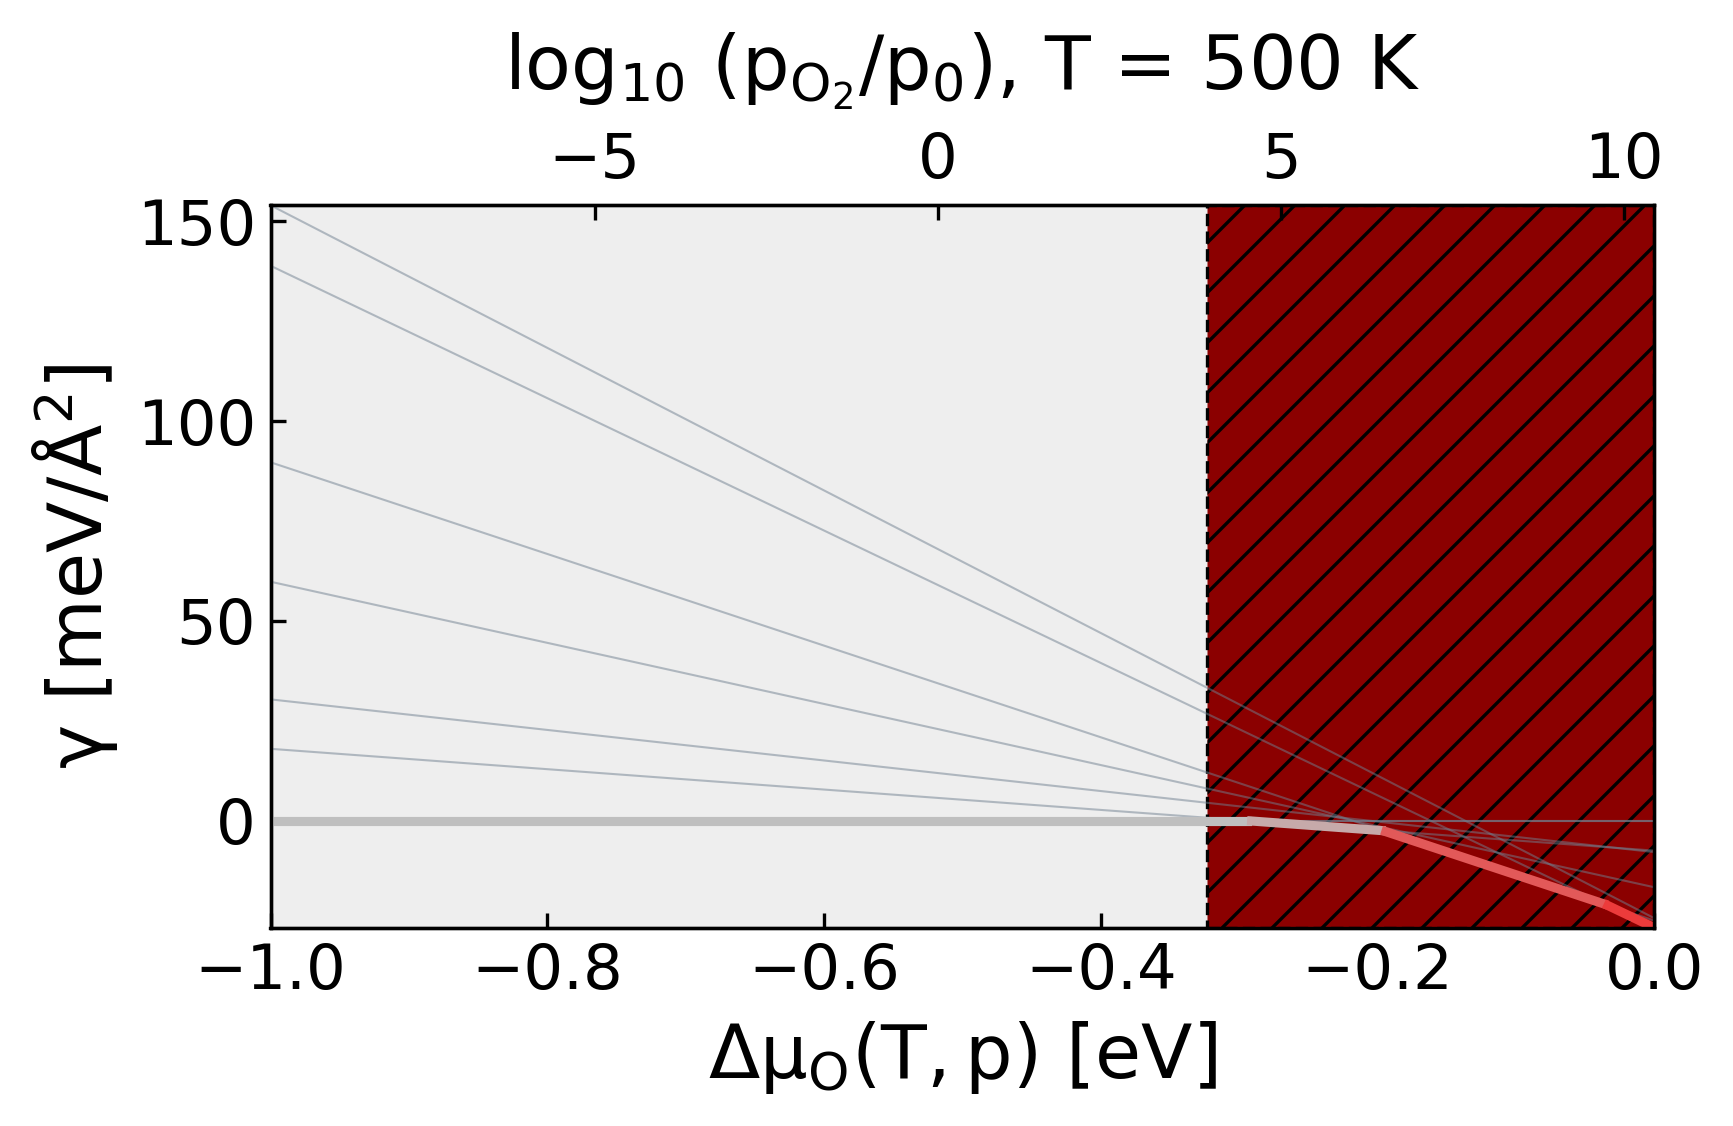

In [6]:
from IPython.display import Image, display

phase_plot_path = results_dir / "phase_diagram.png"

analysis = analyze_phase_diagram_results(
    trajectory_path=str(combined_traj_path),
    host_symbol=metal_species,
    oxygen_symbol=gas_species,
    idx_ref=0,
    n_bins=300,
    delta_mu_o_min=float(delta_mu_o_values.min()),
    delta_mu_o_max=float(0),
    z_threshold=cell_bottom,
    T=temperature,
    xlim=(float(delta_mu_o_values.min()), 0),
    output_plot_path=str(phase_plot_path),
    save_plot=True,
    show_plot=False,
)

print("Phase transition points (delta mu_O):")
print(analysis["transitions_delta_mu_o"])
print("Phase order (configuration indices):")
print(analysis["phase_order_conf_idx"])
print(f"Plot saved to: {analysis['plot_path']}")

display(Image(filename=str(phase_plot_path)))

In [20]:
delta_mu_o_values.max()

np.float64(-0.2)